# 数据准备

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from datasets import load_from_disk
# 读取音频嵌入数据
embeddings_path = "/content/drive/MyDrive/yambda_500m/embeddings"
embeddings = load_from_disk(embeddings_path)

Loading dataset from disk:   0%|          | 0/32 [00:00<?, ?it/s]

In [3]:
# 读取用户物品交互数据
multi_event_path = "/content/drive/MyDrive/yambda_500m/multi_event"
multi_event = load_from_disk(multi_event_path)

Loading dataset from disk:   0%|          | 0/29 [00:00<?, ?it/s]

In [4]:
# 读取艺人专辑歌曲关系图
album_item_mapping_path = "/content/drive/MyDrive/yambda_500m/album_item_mapping"
album_item_mapping = load_from_disk(album_item_mapping_path)
artist_item_mapping_path = "/content/drive/MyDrive/yambda_500m/artist_item_mapping"
artist_item_mapping = load_from_disk(artist_item_mapping_path)

In [5]:
import torch

print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 是否可用: {torch.cuda.is_available()}")

PyTorch 版本: 2.10.0+cu128
CUDA 是否可用: True


In [6]:
# 🔥 开启 TF32 加速模式 (A100 显卡必备)
# 'high' 表示允许使用 TensorFloat32，精度略微下降但速度飞快
torch.set_float32_matmul_precision('high')

# 数据预处理和可视化分析

In [7]:
import pandas as pd
import numpy as np
import torch
import time
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

start_time = time.time()

print("🚀 第一步：极速加载数据到内存...")
# 只提取我们需要的列，避免加载无用数据
cols_to_keep = ['uid', 'item_id', 'timestamp', 'is_organic', 'event_type', 'played_ratio_pct']

# 利用底层的 PyArrow 引擎，瞬间转为 Pandas DataFrame
df = multi_event.select_columns(cols_to_keep).to_pandas()

print("🧹 第二步：正在进行高标准的数据清洗...")
# 瞬间填充空值为 0
df['played_ratio_pct'] = df['played_ratio_pct'].fillna(0.0)

# Pandas 向量化条件过滤，这在底层是 C 语言运行的，只需几秒钟
mask_like = df['event_type'] == 'like'
mask_listen = (df['event_type'] == 'listen') & (df['played_ratio_pct'] >= 50.0)

valid_mask = (mask_like | mask_listen)

total_raw = len(df)
# 应用掩码，保留干净数据
df_clean = df[valid_mask]
total_valid = len(df_clean)

# 修改后：保护长尾物品的单向过滤
print("🧹 正在进行【保留长尾】的高标准清洗...")

# 1. 物品端：极轻度过滤（比如只过滤掉全站只听过 1 次的绝对噪音，保留 >=2 的所有长尾）
min_item_inter = 2
item_counts = df_clean.groupby('item_id').size()
valid_i = item_counts[item_counts >= min_item_inter].index
df_clean = df_clean[df_clean['item_id'].isin(valid_i)]

# 2. 用户端：严格过滤（保证每个用户至少有 5 条记录，才能切分出 训练集/测试集）
min_user_inter = 5
user_counts = df_clean.groupby('uid').size()
valid_u = user_counts[user_counts >= min_user_inter].index
df_clean = df_clean[df_clean['uid'].isin(valid_u)]

print(f"   -> 原始交互总数: {total_raw}")
print(f"   -> 清洗后有效交互数: {total_valid} (剔除了 {total_raw - total_valid} 条无效交互)")

print("⏳ 第三步：提取纯 C 级底层数组并进行全局排序...")
# 直接提取 DataFrame 的 .values (底层就是连续的 NumPy C 数组)
uids = df_clean['uid'].values
item_ids = df_clean['item_id'].values
timestamps = df_clean['timestamp'].values

# 联合排序 (按 uid 排，uid 内部按 timestamp 排)
sort_idx = np.lexsort((timestamps, uids))
sorted_uids = uids[sort_idx]
sorted_items = item_ids[sort_idx]

print("⚡ 第四步：极速切分用户序列...")
# 核心加速魔法：利用 numpy 的 C 级数组切分
change_indices = np.where(sorted_uids[:-1] != sorted_uids[1:])[0] + 1
unique_uids = np.concatenate(([sorted_uids[0]], sorted_uids[change_indices]))
split_items = np.split(sorted_items, change_indices)

print("📦 第五步：正在组装用户序列字典...")
# 组装字典
user_seqs = {
    u.item(): items.tolist()
    for u, items in tqdm(zip(unique_uids, split_items), total=len(unique_uids), desc="组装进度", unit="user")
}

print(f"✅ 序列构建完成！总耗时: {time.time() - start_time:.2f} 秒\n")


🚀 第一步：极速加载数据到内存...
🧹 第二步：正在进行高标准的数据清洗...
🧹 正在进行【保留长尾】的高标准清洗...
   -> 原始交互总数: 480255564
   -> 清洗后有效交互数: 304024436 (剔除了 176231128 条无效交互)
⏳ 第三步：提取纯 C 级底层数组并进行全局排序...
⚡ 第四步：极速切分用户序列...
📦 第五步：正在组装用户序列字典...


组装进度: 100%|██████████| 98929/98929 [00:16<00:00, 5917.98user/s]

✅ 序列构建完成！总耗时: 259.92 秒



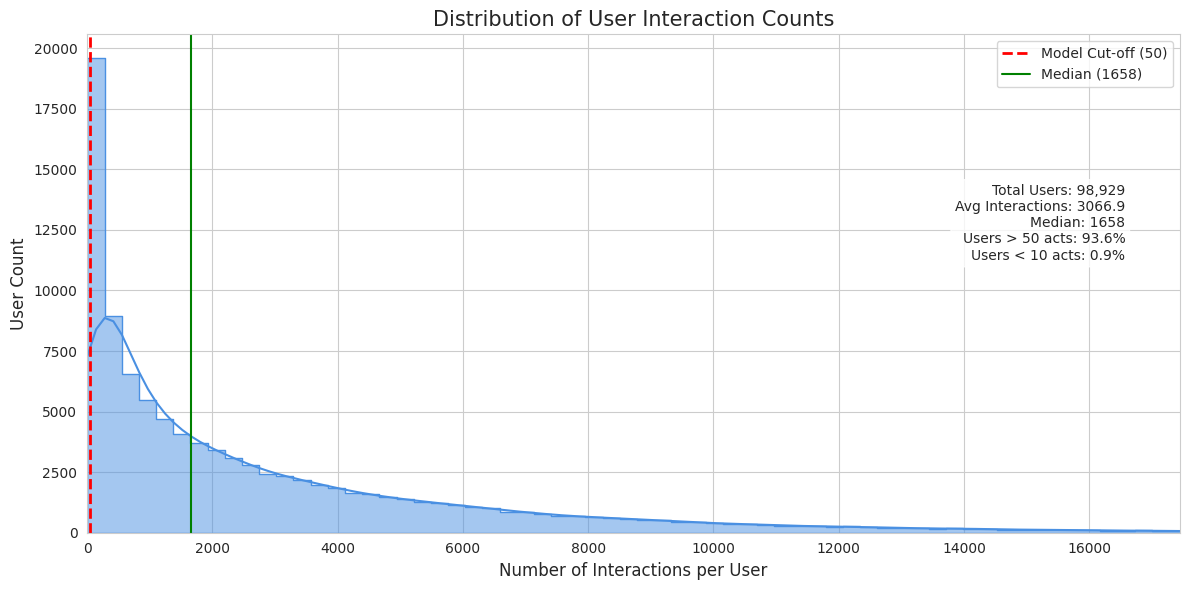

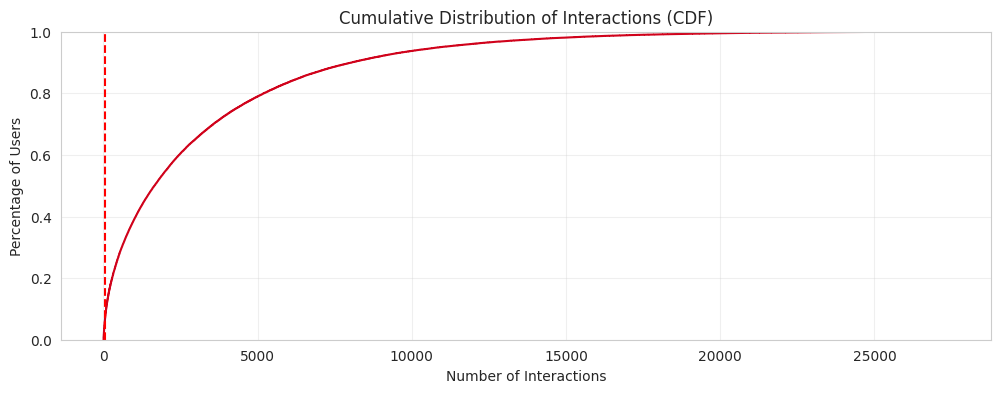

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 统计每个用户的交互序列长度
# 假设你已经运行了构建 user_seqs 的单元格
if 'user_seqs' in locals():
    # 提取所有用户的序列长度
    lengths = [len(seq) for seq in user_seqs.values()]
    lengths = np.array(lengths)

    # 2. 计算关键统计指标
    mean_len = np.mean(lengths)
    median_len = np.median(lengths)
    max_len_val = np.max(lengths)
    p90 = np.percentile(lengths, 90)

    # 超过 50 次和少于 10 次的比例
    over_50 = (lengths > 50).mean() * 100
    under_10 = (lengths < 10).mean() * 100

    # 3. 开始绘图
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    # 绘制直方图 (使用对数坐标以便看清长尾)
    sns.histplot(lengths, bins=100, kde=True, color='#4A90E2', element="step")

    # 添加截断基准线 (50次)
    plt.axvline(x=50, color='red', linestyle='--', linewidth=2, label=f'Model Cut-off (50)')
    plt.axvline(x=median_len, color='green', linestyle='-', linewidth=1.5, label=f'Median ({median_len:.0f})')

    # 修饰图表
    plt.title('Distribution of User Interaction Counts', fontsize=15)
    plt.xlabel('Number of Interactions per User', fontsize=12)
    plt.ylabel('User Count', fontsize=12)

    # 设置 X 轴范围（截取到 P99 左右，防止极个别超级活跃用户拉长坐标轴）
    plt.xlim(0, np.percentile(lengths, 99))

    # 添加信息文本框
    stats_text = (f"Total Users: {len(lengths):,}\n"
                  f"Avg Interactions: {mean_len:.1f}\n"
                  f"Median: {median_len:.0f}\n"
                  f"Users > 50 acts: {over_50:.1f}%\n"
                  f"Users < 10 acts: {under_10:.1f}%")
    plt.text(0.95, 0.7, stats_text, transform=plt.gca().transAxes,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4. 辅助观察：累积分布图 (CDF)
    plt.figure(figsize=(12, 4))
    sns.ecdfplot(lengths, color='#D0021B')
    plt.axvline(x=50, color='red', linestyle='--')
    plt.title('Cumulative Distribution of Interactions (CDF)')
    plt.xlabel('Number of Interactions')
    plt.ylabel('Percentage of Users')
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("❌ 请确保先运行了构建 user_seqs 的单元格！")

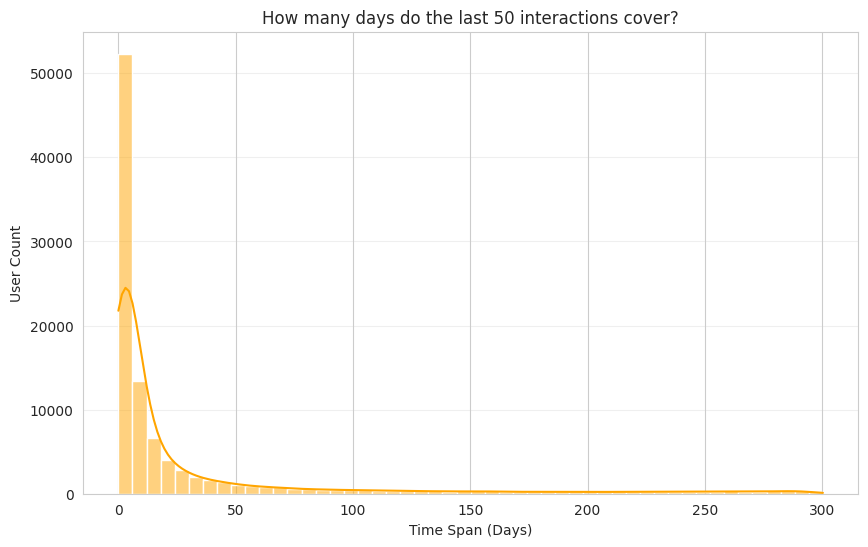

统计用户数: 98929
平均覆盖天数: 28.27 天
中位数: 5.17 天


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 对整个 DataFrame 按照 uid 和时间戳进行排序 (确保取出的是最后 50 次)
# 这一步是所有高效操作的基础
df_sorted = df_clean.sort_values(by=['uid', 'timestamp'])

# 2. 利用 groupby 和 tail(50) 瞬间获取每个用户最近的最多 50 次交互
# 这是 Pandas 的底层 C 实现，比循环快成千上万倍
recent_50 = df_sorted.groupby('uid').tail(50)

# 3. 再次利用聚合函数计算每个用户在这 50 次交互中的最大、最小时间戳以及交互次数
span_df = recent_50.groupby('uid')['timestamp'].agg(
    min_ts='min',
    max_ts='max',
    count='count'
)

# 4. 过滤掉交互次数少于 2 次的用户（对应你原代码的 if len(items) >= 2）
span_df = span_df[span_df['count'] >= 2].copy()

# 5. 计算时间跨度（天）
# 假设 timestamp 是以秒为单位的 Unix 时间戳
span_df['span_days'] = (span_df['max_ts'] - span_df['min_ts']) / (24 * 3600)
time_spans = span_df['span_days'].values

# 6. 绘图
plt.figure(figsize=(10, 6))
sns.histplot(time_spans, bins=50, kde=True, color='orange')
plt.title('How many days do the last 50 interactions cover?')
plt.xlabel('Time Span (Days)')
plt.ylabel('User Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 打印一下统计结果辅助分析
print(f"统计用户数: {len(time_spans)}")
print(f"平均覆盖天数: {time_spans.mean():.2f} 天")
print(f"中位数: {pd.Series(time_spans).median():.2f} 天")

In [10]:
# ==========================================
# ✂️ 划分数据集与构建 PyTorch Dataset
# ==========================================
train_seqs, val_seqs, test_seqs = {}, {}, {}

for uid, seq in tqdm(user_seqs.items(), desc="划分数据集", unit="user"):
    if len(seq) < 3:
        continue
    train_seqs[uid] = seq[:-2]
    val_seqs[uid] = seq[:-1]
    test_seqs[uid] = seq

print(f"\n✅ 有效训练用户数: {len(train_seqs)}")

class SequenceDataset(Dataset):
    def __init__(self, user_seqs, max_len=50):
        self.uids = list(user_seqs.keys())
        self.seqs = [user_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        seq = seq[-self.max_len-1:]

        pad_len = self.max_len + 1 - len(seq)
        seq = [0] * pad_len + seq

        x = torch.tensor(seq[:-1], dtype=torch.long)
        y = torch.tensor(seq[1:], dtype=torch.long)
        return x, y

MAX_SEQ_LEN = 50
train_dataset = SequenceDataset(train_seqs, max_len=MAX_SEQ_LEN)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

划分数据集: 100%|██████████| 98929/98929 [00:11<00:00, 8977.23user/s] 



✅ 有效训练用户数: 98929


In [11]:
print("🚀 正在构建全局对齐的声学特征矩阵...")
start_emb_time = time.time()

# 1. 将 embeddings 数据集极速转为 Pandas DataFrame
df_emb = embeddings.select_columns(['item_id', 'embed']).to_pandas()

# 2. 找到全局最大的 item_id，以确定我们需要多大的词表 (Vocabulary Size)
# 确保矩阵的行数足够容纳所有的 item_id
max_item_id = max(df_clean['item_id'].max(), df_emb['item_id'].max())
feature_dim = len(df_emb.iloc[0]['embed'])

# 3. 初始化全 0 矩阵 (行数为 max_item_id + 1，第 0 行自然被保留为 0 用于 Padding)
track_vectors = np.zeros((max_item_id + 1, feature_dim), dtype=np.float32)

# 4. 利用 NumPy 的高级索引 (Advanced Indexing) 瞬间将特征填入对应行
# df_emb['item_id'].values 作为行索引，精准对齐
track_vectors[df_emb['item_id'].values] = np.vstack(df_emb['embed'].values)

num_tracks = max_item_id # 这将是我们传入模型的物品总量

print(f"✅ 特征矩阵构建完成！")
print(f"   -> 矩阵形状: {track_vectors.shape} (行数=词表大小+1, 列数=特征维度)")
print(f"   -> 总耗时: {time.time() - start_emb_time:.2f} 秒\n")

🚀 正在构建全局对齐的声学特征矩阵...
✅ 特征矩阵构建完成！
   -> 矩阵形状: (9390624, 128) (行数=词表大小+1, 列数=特征维度)
   -> 总耗时: 126.80 秒



# 定义验证集与验证函数

In [12]:
# ==========================================
# 0. 补全缺失的验证集定义 (解决 NameError)
# ==========================================
from torch.utils.data import Dataset, DataLoader

class ValSequenceDataset(Dataset):
    def __init__(self, val_seqs, max_len=50):
        self.uids = list(val_seqs.keys())
        self.seqs = [val_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        # 验证集：用倒数第二首 (target) 之前的序列 (hist) 进行预测
        target = seq[-1]
        hist = seq[:-1]

        hist = hist[-self.max_len:]
        pad_len = self.max_len - len(hist)
        hist = [0] * pad_len + hist

        return torch.tensor(hist, dtype=torch.long), torch.tensor(target, dtype=torch.long)

# 确保 MAX_SEQ_LEN 已经定义（之前我们设为 50）
if 'MAX_SEQ_LEN' not in locals():
    MAX_SEQ_LEN = 50

# 创建验证集加载器
val_dataset = ValSequenceDataset(val_seqs, max_len=MAX_SEQ_LEN)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

print("✅ val_loader 已成功定义！现在可以重新运行训练单元格了。")

✅ val_loader 已成功定义！现在可以重新运行训练单元格了。


In [13]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score # 🌟 补上这个关键导入

@torch.no_grad()
def evaluate_auc_pro(model, val_loader, num_items, device):
    model.eval()
    all_targets, all_preds = [], []

    for x, target in val_loader:
        x, target = x.to(device), target.to(device)

        # 强制使用 float32 避免半精度带来的数值不稳定
        fused_out = model(x).float()
        last_step_state = fused_out[:, -1, :]

        # 计算正样本得分 (L2 归一化后的点积)
        pos_embs = model.get_item_representation(target).float()
        pos_scores = (last_step_state * pos_embs).sum(dim=-1, keepdim=True)

        # 负样本随机采样 99 个
        negatives = torch.randint(1, num_items + 1, (x.size(0), 99), device=device)
        neg_embs = model.get_item_representation(negatives).float()
        neg_scores = (last_step_state.unsqueeze(1) * neg_embs).sum(dim=-1)

        # 转换为 numpy 并清除 NaN (双重保险)
        scores = torch.cat([pos_scores, neg_scores], dim=1).view(-1).cpu().numpy()
        scores = np.nan_to_num(scores, nan=0.0)

        all_preds.append(scores)
        all_targets.append(torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)], dim=1).view(-1).cpu().numpy())

    # 计算全局 AUC
    y_true = np.concatenate(all_targets)
    y_score = np.concatenate(all_preds)

    return roc_auc_score(y_true, y_score)

print("✅ 所有库已导入，验证函数 evaluate_auc_pro 已准备就绪！")

✅ 所有库已导入，验证函数 evaluate_auc_pro 已准备就绪！


# 纯ID序列模型

## 模型定义

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class FDSA_ID_Only(nn.Module):
    def __init__(self, num_items, item_dim=64, max_seq_len=50, num_heads=4, num_layers=2, dropout=0.2):
        super(FDSA_ID_Only, self).__init__()
        self.max_seq_len = max_seq_len

        # 1. 只有 ID Embedding，没有任何多模态特征
        self.item_emb = nn.Embedding(num_items + 1, item_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_seq_len, item_dim)

        # 2. 单流 Transformer (仅处理 ID)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=item_dim, nhead=num_heads,
            dim_feedforward=item_dim * 4, dropout=dropout, batch_first=True
        )
        self.id_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)

    def forward(self, seqs):
        device = seqs.device
        batch_size, seq_len = seqs.size()

        padding_mask = (seqs == 0)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len, device=device).bool()
        positions = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, seq_len)
        pos_embeddings = self.pos_emb(positions)

        # 纯 ID 流前向传播
        id_embs = self.item_emb(seqs) + pos_embeddings
        id_out = self.id_encoder(self.dropout(id_embs), mask=causal_mask, src_key_padding_mask=padding_mask)

        # 直接输出归一化隐状态
        return F.normalize(id_out, p=2, dim=-1, eps=1e-8)

    def get_item_representation(self, item_ids):
        # 物品表征仅由 ID 构成
        e_id = self.item_emb(item_ids)
        return F.normalize(e_id, p=2, dim=-1, eps=1e-8)

# 初始化纯 ID 模型
model_id_only = FDSA_ID_Only(
    num_items=num_tracks,
    item_dim=64,
    num_heads=4,
    num_layers=2
).to(device)

print("✅ FDSA_ID_Only (w/o Acoustic) 定义并初始化完毕！")

✅ FDSA_ID_Only (w/o Acoustic) 定义并初始化完毕！


## 模型训练

In [15]:
optimizer_id = torch.optim.Adam(model_id_only.parameters(), lr=1e-3)
criterion_id = nn.CrossEntropyLoss()
scaler_id = GradScaler('cuda')

temperature = 0.2
best_auc_id = 0.5
patience = 5
patience_counter = 0

for epoch in range(100):
    model_id_only.train()
    total_loss = 0.0
    start_t = time.time()

    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer_id.zero_grad()

        with autocast(device_type='cuda', dtype=torch.float16):
            h_seq = model_id_only(x)

            h_flat = h_seq.view(-1, h_seq.size(-1))
            y_flat = y.view(-1)
            valid_mask = (y_flat != 0)

            h_valid = h_flat[valid_mask]
            y_valid = y_flat[valid_mask]

            e_target = model_id_only.get_item_representation(y_valid)

            logits = torch.matmul(h_valid, e_target.t()) / temperature
            labels = torch.arange(h_valid.size(0), device=device)
            loss = criterion_id(logits, labels)

        scaler_id.scale(loss).backward()
        scaler_id.unscale_(optimizer_id)
        torch.nn.utils.clip_grad_norm_(model_id_only.parameters(), max_norm=1.0)
        scaler_id.step(optimizer_id)
        scaler_id.update()
        total_loss += loss.item()

        if (i+1) % 100 == 0:
            print(f"   Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    # 验证阶段 (复用之前定义好的 evaluate_auc_pro)
    val_auc = evaluate_auc_pro(model_id_only, val_loader, num_tracks, device)
    print(f"✅ Epoch {epoch+1} | Avg Loss: {total_loss/len(train_loader):.4f} | Val AUC: {val_auc:.4f} | Time: {time.time()-start_t:.1f}s")

    if val_auc > best_auc_id :
        best_auc_id = val_auc
        patience_counter = 0
        # 另存为纯 ID 模型的权重
        torch.save(model_id_only.state_dict(), 'best_model_id_only.pth')
        print(f"🌟 新纪录！保存消融模型至 best_model_id_only.pth")
    else:
        patience_counter += 1
        print(f"📉 AUC 未提升 | 早停计数: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("🛑 停止训练")
            break
    print("-" * 50)

   Batch 100/387 | Loss: 9.5128
   Batch 200/387 | Loss: 9.4452
   Batch 300/387 | Loss: 9.3669
✅ Epoch 1 | Avg Loss: 9.4564 | Val AUC: 0.5543 | Time: 36.3s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 9.4045
   Batch 200/387 | Loss: 9.3973
   Batch 300/387 | Loss: 9.3454
✅ Epoch 2 | Avg Loss: 9.3709 | Val AUC: 0.5926 | Time: 34.7s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 9.2882
   Batch 200/387 | Loss: 9.2803
   Batch 300/387 | Loss: 9.2198
✅ Epoch 3 | Avg Loss: 9.2517 | Val AUC: 0.6421 | Time: 34.6s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 9.1641
   Batch 200/387 | Loss: 9.1603
   Batch 300/387 | Loss: 9.0679
✅ Epoch 4 | Avg Loss: 9.1315 | Val AUC: 0.6827 | Time: 41.4s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | L

## 模型评估

In [16]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import itertools

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ==========================================
# 1. 极速计算全局热度与音乐特定属性 (基于干净的训练集序列)
# ==========================================
print("📈 正在极速计算音乐专属评价属性...")
num_tracks = track_vectors.shape[0]

# 🌟 核心优化：瞬间展平所有用户的训练序列，避免 Python 双重 for 循环
flat_items = list(itertools.chain.from_iterable(train_seqs.values()))

# 将展平的列表一次性送入 GPU，利用底层的 C/CUDA 极速计算频次
flat_items_tensor = torch.tensor(flat_items, dtype=torch.long, device=device)
track_counts = torch.bincount(flat_items_tensor, minlength=num_tracks + 1)

# 排除 padding (0) 的统计干扰
track_counts[0] = 0

# A. 提取热门歌曲作为困难负样本池 (取 min 防止越界)
POOL_SIZE = min(50000, num_tracks)
top_popular_tracks = torch.topk(track_counts, POOL_SIZE).indices

# B. 计算新颖度概率 (Novelty)
track_probs = (track_counts / track_counts.sum())
track_novelty = -torch.log2(track_probs + 1e-9)

# C. 计算头部物品掩码 (定义 Top 5000 为头部金曲)
head_indices = torch.topk(track_counts, min(5000, num_tracks)).indices
is_head_item = torch.zeros(num_tracks + 1, dtype=torch.bool, device=device)
is_head_item[head_indices] = True

# ==========================================
# 2. 构建测试集 DataLoader (Leave-One-Out)
# ==========================================
class TestSequenceDataset(Dataset):
    def __init__(self, test_seqs, max_len=50):
        self.uids = list(test_seqs.keys())
        self.seqs = [test_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        # 测试集：用除了最后一首之外的所有历史去预测最后一首
        target = seq[-1]
        hist = seq[:-1][-self.max_len:]
        pad_len = self.max_len - len(hist)
        hist = [0] * pad_len + hist
        return torch.tensor(hist, dtype=torch.long), torch.tensor(target, dtype=torch.long)

test_dataset = TestSequenceDataset(test_seqs, max_len=MAX_SEQ_LEN)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

📈 正在极速计算音乐专属评价属性...


In [17]:
import numpy as np
from tqdm import tqdm

# 1. 加载纯 ID 模型的巅峰权重
model_id_only.load_state_dict(torch.load('best_model_id_only.pth'))
model_id_only.eval()
print("✅ 已成功加载纯 ID 模型权重！")

# 2. 初始化结果收集器
K_LIST = [10, 100]
results_id = {k: {'Recall': [], 'NDCG': [], 'Novelty': [], 'Diversity': [], 'LongTail': []} for k in K_LIST}
global_cov_id = {k: set() for k in K_LIST}

raw_acoustic_features = torch.tensor(track_vectors, device=device, dtype=torch.float32)

print(f"🚀 开始硬核评估 (测试序列数: {len(test_dataset)}，候选集: 1正+999负)...")

with torch.no_grad():
    for x, target in tqdm(test_loader, desc="评测进度"):
        x, target = x.to(device), target.to(device)
        batch_size = x.size(0)

        # 纯 ID 模型的隐状态
        fused_out = model_id_only(x)
        batch_user_vecs = fused_out[:, -1, :].unsqueeze(1)

        # 候选集拼装
        pos_tids = target.unsqueeze(1)
        neg_idx = torch.randint(0, POOL_SIZE, (batch_size, 999), device=device)
        neg_candidates = top_popular_tracks[neg_idx]
        candidates_tids = torch.cat([pos_tids, neg_candidates], dim=1)

        # 获取纯 ID 表征
        batch_cand_vecs = model_id_only.get_item_representation(candidates_tids)

        scores = (batch_user_vecs * batch_cand_vecs).sum(dim=-1)
        _, top_indices = torch.topk(scores, k=max(K_LIST), dim=1)
        rec_tids = candidates_tids.gather(1, top_indices)

        for k in K_LIST:
            tk_indices = top_indices[:, :k]
            tk_tids = rec_tids[:, :k]

            hits = (tk_indices == 0).float()
            results_id[k]['Recall'].extend(hits.sum(dim=1).cpu().numpy())

            for row_hits in hits:
                if row_hits.sum() > 0:
                    rank = (row_hits == 1).nonzero(as_tuple=True)[0].item()
                    results_id[k]['NDCG'].append(1.0 / np.log2(rank + 2))
                else:
                    results_id[k]['NDCG'].append(0.0)

            nov = track_novelty[tk_tids].mean(dim=1).cpu().numpy()
            results_id[k]['Novelty'].extend(nov)

            tail_rate = (~is_head_item[tk_tids]).float().mean(dim=1).cpu().numpy()
            results_id[k]['LongTail'].extend(tail_rate)

            # 🌟 重点：依然使用真实的声学特征来算 Diversity！
            rec_embs = raw_acoustic_features[tk_tids]
            norm_embs = F.normalize(rec_embs, p=2, dim=-1)
            sim_matrix = torch.bmm(norm_embs, norm_embs.transpose(1, 2))
            mask = ~torch.eye(k, dtype=torch.bool, device=device).unsqueeze(0).expand(batch_size, k, k)
            mean_sim = sim_matrix[mask].reshape(batch_size, k, k-1).mean(dim=(1,2))
            diversity = (1.0 - mean_sim).cpu().numpy()
            results_id[k]['Diversity'].extend(diversity)

            unique_tids = set(tk_tids.reshape(-1).cpu().numpy())
            global_cov_id[k].update(unique_tids)

print("\n" + "="*55)
print("🛑 实验报告：FDSA (w/o Acoustic) - 纯 ID 基线")
print("="*55)

for k in K_LIST:
    print(f"🎯 【Top-{k} 评估指标】:")
    print(f"   📈 精准度类 (Accuracy):")
    print(f"      - Recall@{k} / HR@{k} : {np.mean(results_id[k]['Recall']):.4f}")
    print(f"      - NDCG@{k}           : {np.mean(results_id[k]['NDCG']):.4f}")

    print(f"   🎵 音乐特化类 (Beyond-Accuracy):")
    cov_ratio = len(global_cov_id[k]) / POOL_SIZE
    print(f"      - Coverage@{k} (系统覆盖率): {cov_ratio:.4f} ({len(global_cov_id[k])} 首)")
    print(f"      - Novelty@{k}  (平均新颖度): {np.mean(results_id[k]['Novelty']):.4f} bit")
    print(f"      - Diversity@{k}(声学多样性): {np.mean(results_id[k]['Diversity']):.4f} (越大越多元)")
    print(f"      - LongTail@{k} (长尾挖掘率): {np.mean(results_id[k]['LongTail']):.4f}")
    print("-" * 55)

✅ 已成功加载纯 ID 模型权重！
🚀 开始硬核评估 (测试序列数: 98929，候选集: 1正+999负)...


评测进度: 100%|██████████| 194/194 [00:32<00:00,  5.96it/s]



🛑 实验报告：FDSA (w/o Acoustic) - 纯 ID 基线
🎯 【Top-10 评估指标】:
   📈 精准度类 (Accuracy):
      - Recall@10 / HR@10 : 0.4682
      - NDCG@10           : 0.3380
   🎵 音乐特化类 (Beyond-Accuracy):
      - Coverage@10 (系统覆盖率): 1.1616 (58082 首)
      - Novelty@10  (平均新颖度): 16.3125 bit
      - Diversity@10(声学多样性): 0.5655 (越大越多元)
      - LongTail@10 (长尾挖掘率): 0.8132
-------------------------------------------------------
🎯 【Top-100 评估指标】:
   📈 精准度类 (Accuracy):
      - Recall@100 / HR@100 : 0.7941
      - NDCG@100           : 0.4043
   🎵 音乐特化类 (Beyond-Accuracy):
      - Coverage@100 (系统覆盖率): 1.2728 (63642 首)
      - Novelty@100  (平均新颖度): 16.5960 bit
      - Diversity@100(声学多样性): 0.7240 (越大越多元)
      - LongTail@100 (长尾挖掘率): 0.8708
-------------------------------------------------------


In [18]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import itertools

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 0. 🌟 评测模式终极开关 (一键切换测试环境) 🌟
# ==========================================
# 可选值:
#   'uniform' : 全局均匀抽样 (测试模型的长尾挖掘与全局特征匹配能力，相对公平)
#   'popular' : 热门候选抽样 (测试模型抵抗流行度偏见的极限抗压能力，地狱难度)
SAMPLING_MODE = 'uniform'  # <--- 修改这里即可一键切换！

print(f"⚙️ 当前系统已切换至【{SAMPLING_MODE.upper()}】评测模式！\n")

# ==========================================
# 1. 极速计算全局热度与构建双重候选池
# ==========================================
print("📈 正在极速构建音乐候选池与评价属性...")
num_tracks = track_vectors.shape[0]

# 统计频次
flat_items = list(itertools.chain.from_iterable(train_seqs.values()))
flat_items_tensor = torch.tensor(flat_items, dtype=torch.long, device=device)
track_counts = torch.bincount(flat_items_tensor, minlength=num_tracks + 1)
track_counts[0] = 0 # 排除 padding

# --- A. 准备：全局均匀候选池 (Uniform Pool) ---
valid_track_indices = torch.nonzero(track_counts > 0).squeeze(1)
global_candidate_pool = valid_track_indices
num_valid_tracks = len(global_candidate_pool)

# --- B. 准备：热门困难候选池 (Popular Pool) ---
# 取前 50000 首（或有效歌曲总数的上限）作为热门陪跑池
POPULAR_POOL_SIZE = min(50000, num_valid_tracks)
top_popular_tracks = torch.topk(track_counts, POPULAR_POOL_SIZE).indices

# --- C. 计算新颖度与头部掩码 (用于后续指标) ---
track_probs = (track_counts / track_counts.sum())
track_novelty = -torch.log2(track_probs + 1e-9)

head_threshold = int(0.05 * num_valid_tracks)
head_indices = torch.topk(track_counts, head_threshold).indices
is_head_item = torch.zeros(num_tracks + 1, dtype=torch.bool, device=device)
is_head_item[head_indices] = True

# ==========================================
# 2. 构建测试集 DataLoader (保持不变)
# ==========================================
class TestSequenceDataset(Dataset):
    def __init__(self, test_seqs, max_len=50):
        self.uids = list(test_seqs.keys())
        self.seqs = [test_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        target = seq[-1]
        hist = seq[:-1][-self.max_len:]
        pad_len = self.max_len - len(hist)
        hist = [0] * pad_len + hist
        return torch.tensor(hist, dtype=torch.long), torch.tensor(target, dtype=torch.long)

test_dataset = TestSequenceDataset(test_seqs, max_len=MAX_SEQ_LEN)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

# ==========================================
# 3. 核心评估流程
# ==========================================
# 1. 加载模型权重 (以纯 ID 模型为例，后续测试 FDSA 时替换这两行即可)
# '/content/drive/MyDrive/music/best_model_id_only.pth'
model_id_only.load_state_dict(torch.load('best_model_id_only.pth', map_location=device))
model_id_only.eval()
print("✅ 模型权重已成功加载！")

# 2. 初始化结果收集器
K_LIST = [10, 100]
results = {k: {'Recall': [], 'NDCG': [], 'Novelty': [], 'Diversity': [], 'LongTail': []} for k in K_LIST}
global_cov = {k: set() for k in K_LIST}

raw_acoustic_features = torch.tensor(track_vectors, device=device, dtype=torch.float32)

print(f"🚀 开始盲测 (测试序列: {len(test_dataset)}，负样本采样: 999 选自 {SAMPLING_MODE} 池)...")

with torch.no_grad():
    for x, target in tqdm(test_loader, desc="评测进度"):
        x, target = x.to(device), target.to(device)
        batch_size = x.size(0)

        # 提取用户表征
        fused_out = model_id_only(x)
        batch_user_vecs = fused_out[:, -1, :].unsqueeze(1)

        # ---------------------------------------------------------
        # 🌟 动态抽样逻辑：根据开关选择负样本
        # ---------------------------------------------------------
        pos_tids = target.unsqueeze(1)

        if SAMPLING_MODE == 'uniform':
            neg_idx = torch.randint(0, num_valid_tracks, (batch_size, 999), device=device)
            neg_candidates = global_candidate_pool[neg_idx]
        elif SAMPLING_MODE == 'popular':
            neg_idx = torch.randint(0, POPULAR_POOL_SIZE, (batch_size, 999), device=device)
            neg_candidates = top_popular_tracks[neg_idx]
        else:
            raise ValueError("未知的 SAMPLING_MODE！请设置为 'uniform' 或 'popular'。")

        candidates_tids = torch.cat([pos_tids, neg_candidates], dim=1)
        # ---------------------------------------------------------

        # 获取物品表征并打分
        batch_cand_vecs = model_id_only.get_item_representation(candidates_tids)
        scores = (batch_user_vecs * batch_cand_vecs).sum(dim=-1)
        _, top_indices = torch.topk(scores, k=max(K_LIST), dim=1)
        rec_tids = candidates_tids.gather(1, top_indices)

        # 计算各类指标
        for k in K_LIST:
            tk_indices = top_indices[:, :k]
            tk_tids = rec_tids[:, :k]

            hits = (tk_indices == 0).float()
            results[k]['Recall'].extend(hits.sum(dim=1).cpu().numpy())

            for row_hits in hits:
                if row_hits.sum() > 0:
                    rank = (row_hits == 1).nonzero(as_tuple=True)[0].item()
                    results[k]['NDCG'].append(1.0 / np.log2(rank + 2))
                else:
                    results[k]['NDCG'].append(0.0)

            nov = track_novelty[tk_tids].mean(dim=1).cpu().numpy()
            results[k]['Novelty'].extend(nov)

            tail_rate = (~is_head_item[tk_tids]).float().mean(dim=1).cpu().numpy()
            results[k]['LongTail'].extend(tail_rate)

            rec_embs = raw_acoustic_features[tk_tids]
            norm_embs = F.normalize(rec_embs, p=2, dim=-1)
            sim_matrix = torch.bmm(norm_embs, norm_embs.transpose(1, 2))
            mask = ~torch.eye(k, dtype=torch.bool, device=device).unsqueeze(0).expand(batch_size, k, k)
            mean_sim = sim_matrix[mask].reshape(batch_size, k, k-1).mean(dim=(1,2))
            diversity = (1.0 - mean_sim).cpu().numpy()
            results[k]['Diversity'].extend(diversity)

            unique_tids = set(tk_tids.reshape(-1).cpu().numpy())
            global_cov[k].update(unique_tids)

print("\n" + "="*60)
print(f"🛑 实验报告：纯 ID 基线模型 | 评测模式: 【{SAMPLING_MODE.upper()}】")
print("="*60)

for k in K_LIST:
    print(f"🎯 【Top-{k} 评估指标】:")
    print(f"   📈 精准度类 (Accuracy):")
    print(f"      - Recall@{k} / HR@{k} : {np.mean(results[k]['Recall']):.4f}")
    print(f"      - NDCG@{k}           : {np.mean(results[k]['NDCG']):.4f}")

    print(f"   🎵 音乐特化类 (Beyond-Accuracy):")
    # 覆盖率始终以全局有效歌曲数为分母，这样比较才公平
    cov_ratio = len(global_cov[k]) / num_valid_tracks
    print(f"      - Coverage@{k} (系统覆盖率): {cov_ratio:.4f} ({len(global_cov[k])} 首)")
    print(f"      - Novelty@{k}  (平均新颖度): {np.mean(results[k]['Novelty']):.4f} bit")
    print(f"      - Diversity@{k}(声学多样性): {np.mean(results[k]['Diversity']):.4f} (越大越多元)")
    print(f"      - LongTail@{k} (长尾挖掘率): {np.mean(results[k]['LongTail']):.4f}")
    print("-" * 60)

⚙️ 当前系统已切换至【UNIFORM】评测模式！

📈 正在极速构建音乐候选池与评价属性...
✅ 模型权重已成功加载！
🚀 开始盲测 (测试序列: 98929，负样本采样: 999 选自 uniform 池)...


评测进度: 100%|██████████| 194/194 [00:49<00:00,  3.90it/s]


🛑 实验报告：纯 ID 基线模型 | 评测模式: 【UNIFORM】
🎯 【Top-10 评估指标】:
   📈 精准度类 (Accuracy):
      - Recall@10 / HR@10 : 0.7572
      - NDCG@10           : 0.6125
   🎵 音乐特化类 (Beyond-Accuracy):
      - Coverage@10 (系统覆盖率): 0.2942 (386661 首)
      - Novelty@10  (平均新颖度): 20.5171 bit
      - Diversity@10(声学多样性): 0.7823 (越大越多元)
      - LongTail@10 (长尾挖掘率): 0.6312
------------------------------------------------------------
🎯 【Top-100 评估指标】:
   📈 精准度类 (Accuracy):
      - Recall@100 / HR@100 : 0.8857
      - NDCG@100           : 0.6398
   🎵 音乐特化类 (Beyond-Accuracy):
      - Coverage@100 (系统覆盖率): 0.9872 (1297209 首)
      - Novelty@100  (平均新颖度): 23.5598 bit
      - Diversity@100(声学多样性): 0.8810 (越大越多元)
      - LongTail@100 (长尾挖掘率): 0.8961
------------------------------------------------------------
